# Machine Learning Intermediate course

## Handling missing values

In [1]:
import zipfile
import os
from pathlib import Path
chwd = os.getcwd()

# unzipping the file

with zipfile.ZipFile(Path('data/melb_data.csv.zip'), 'r') as zip_file:
    zip_file.extractall('data/')

### Three Approaches¶
1) A Simple Option: Drop Columns with Missing Values
The simplest option is to drop columns with missing values.

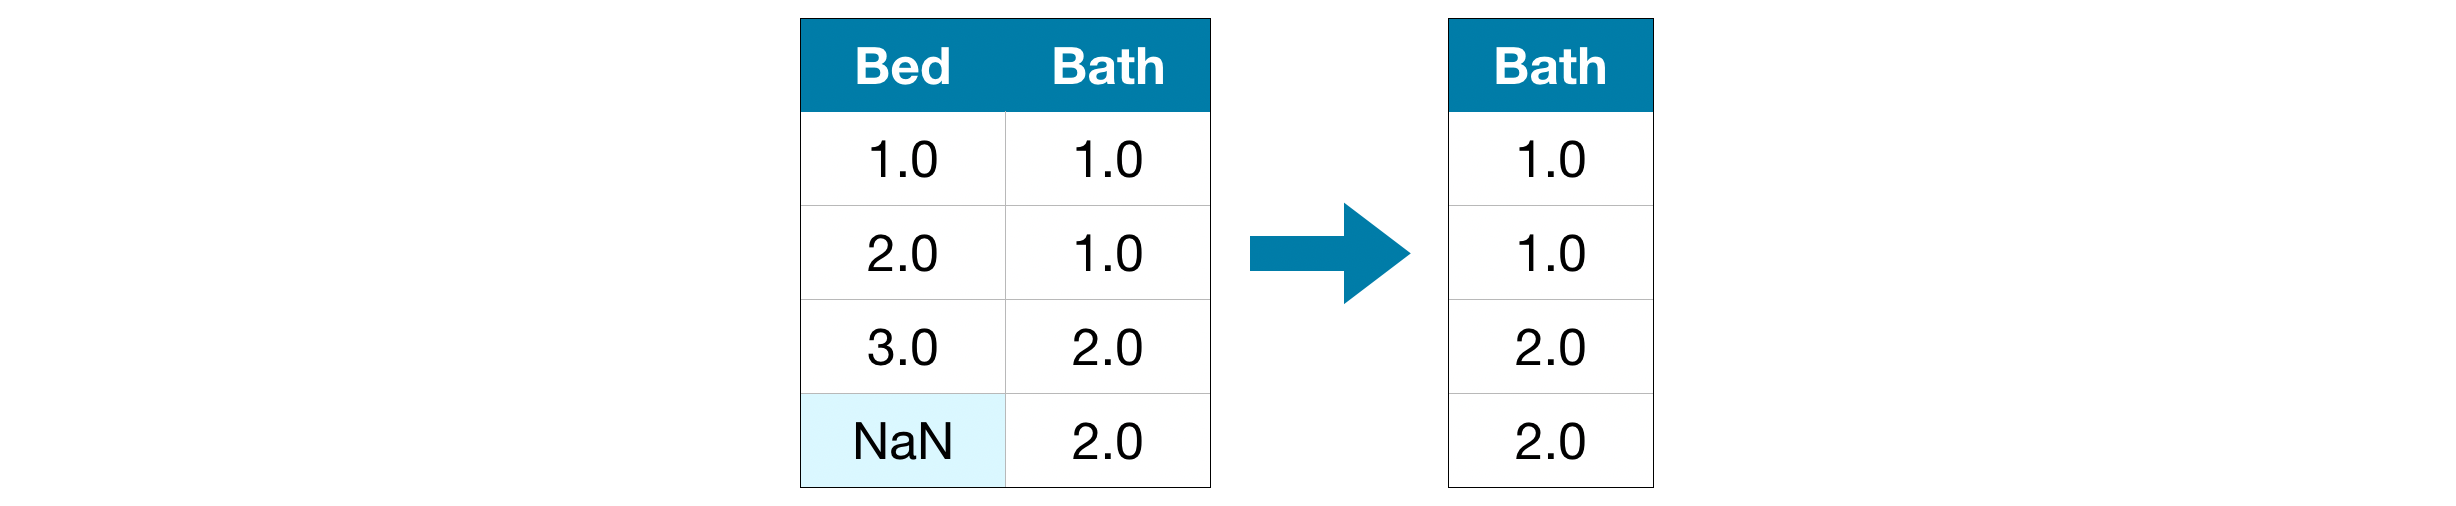
Unless most values in the dropped columns are missing, the model loses access to a lot of (potentially useful!) information with this approach. As an extreme example, consider a dataset with 10,000 rows, where one important column is missing a single entry. This approach would drop the column entirely!

2) A Better Option: Imputation¶
Imputation fills in the missing values with some number. For instance, we can fill in the mean value along each column.

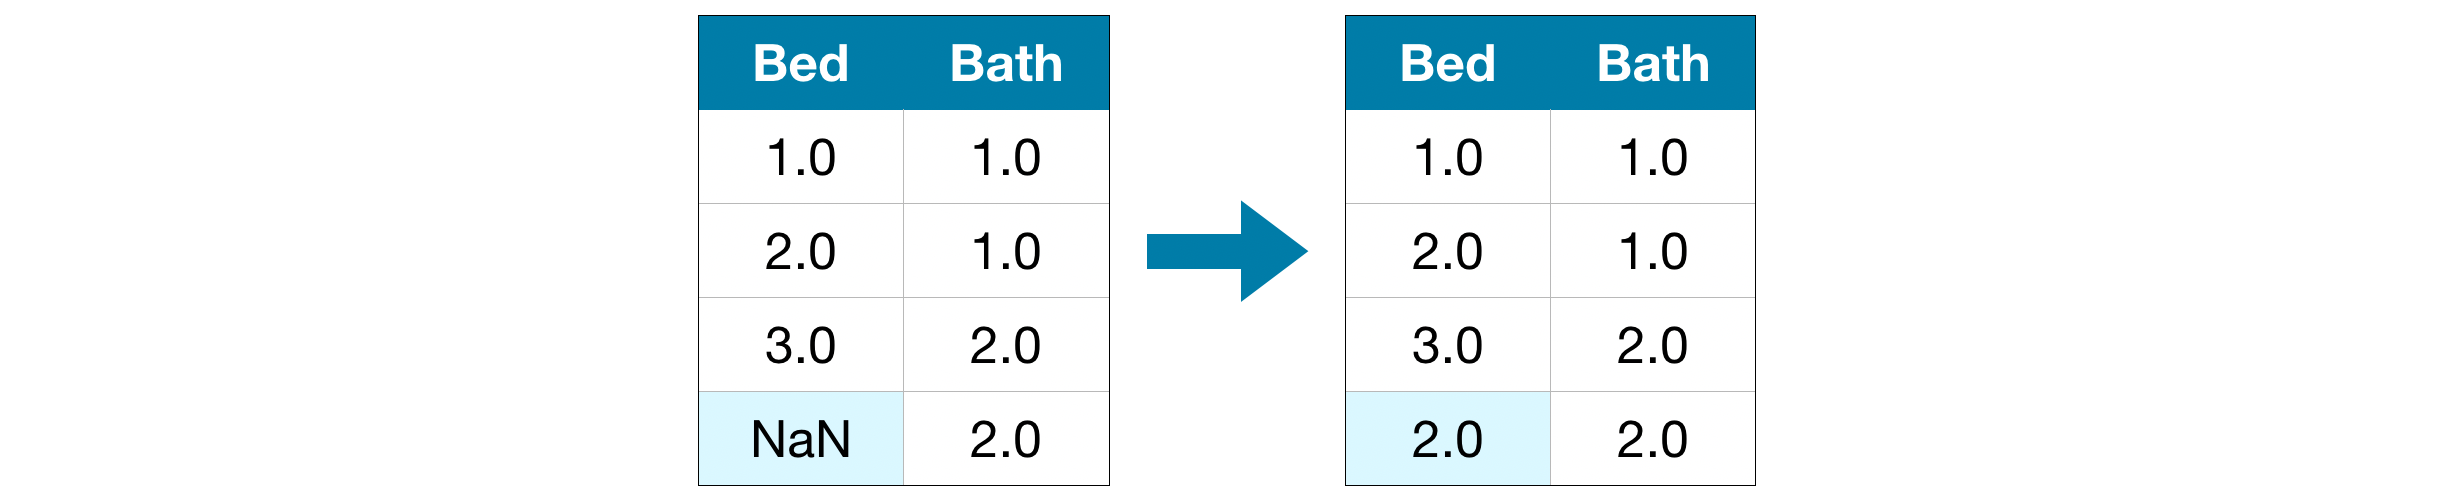

The imputed value won't be exactly right in most cases, but it usually leads to more accurate models than you would get from dropping the column entirely.

3) An Extension To Imputation
Imputation is the standard approach, and it usually works well. However, imputed values may be systematically above or below their actual values (which weren't collected in the dataset). Or rows with missing values may be unique in some other way. In that case, your model would make better predictions by considering which values were originally missing.

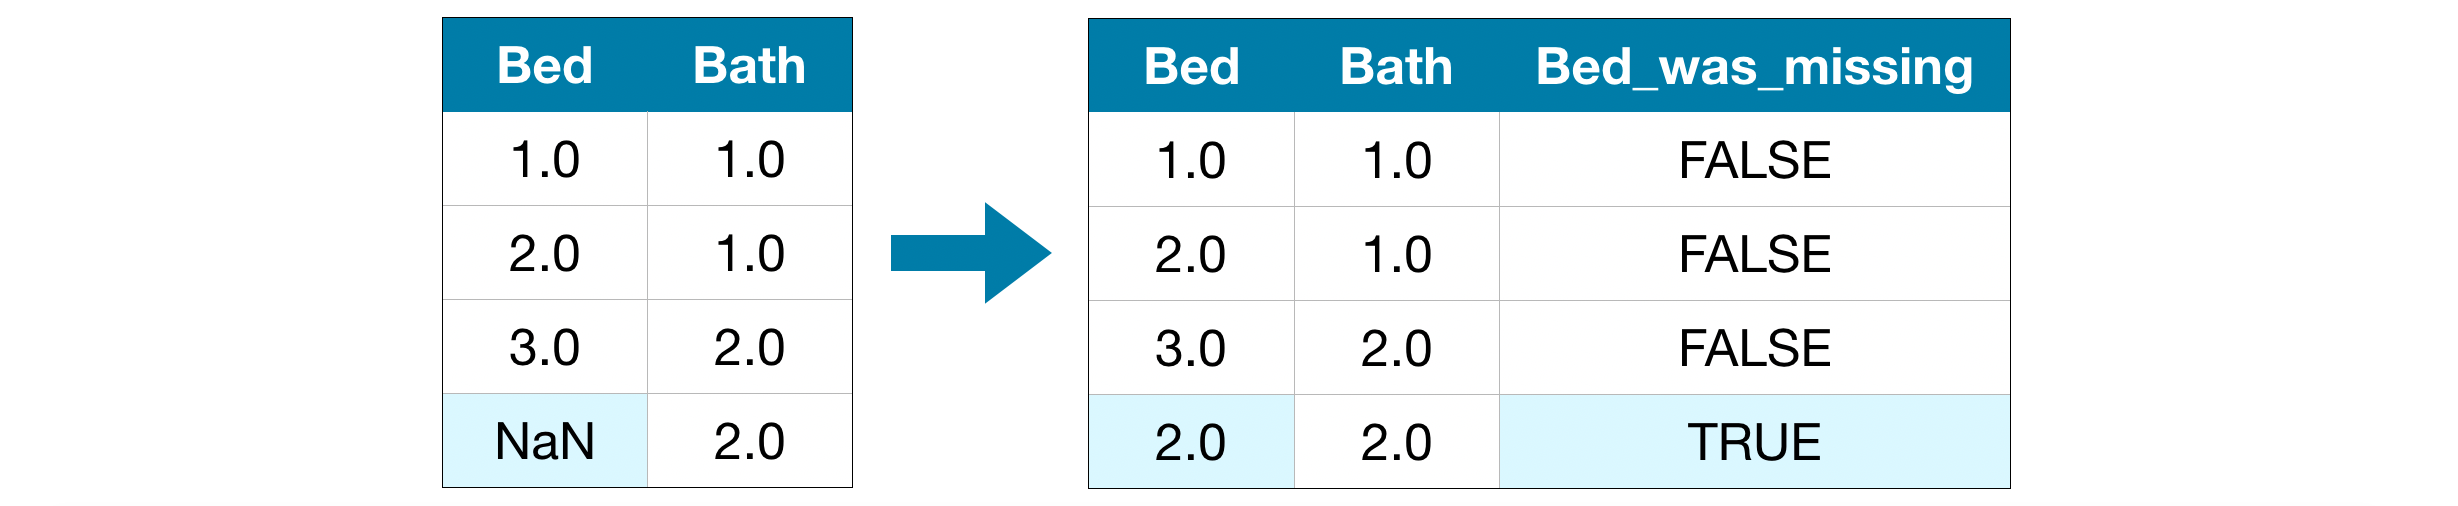

In this approach, we impute the missing values, as before. And, additionally, for each column with missing entries in the original dataset, we add a new column that shows the location of the imputed entries.

In some cases, this will meaningfully improve results. In other cases, it doesn't help at all.

#### Now lets do hands-on

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_csv('data/melb_data.csv')

In [3]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [4]:
features = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']
features_categorical =  [ 'Type', 'Method', 'Regionname', 'Suburb', 'Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']
X = df[features]
y = df.Price

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [6]:
X_train, X_validate, y_train, y_validate = train_test_split(X, y, random_state=10, test_size=0.3)

In [7]:
def check_fillna_score(X_train, X_validate, y_train, y_validate):
    model = RandomForestRegressor(n_estimators=10, random_state=10)
    model.fit(X_train, y_train )
    predictions = model.predict(X_validate)
    mae = mean_absolute_error(predictions, y_validate)
    print(f"value of mean Absolute Error is : {mae}")
    return mae    

#### Testing method 1, Dropping the columns with missing values


In [8]:
cols_with_missing_values = [col for col in X_train.columns if X_train[col].isnull().any()]
X_train_drop = X_train.drop(cols_with_missing_values, axis=1)
X_validate_drop = X_validate.drop(cols_with_missing_values, axis=1)

drop_score = check_fillna_score(X_train_drop, X_validate_drop, y_train, y_validate)

value of mean Absolute Error is : 266343.02391533204


#### Testing method 2 imputating the missing value

In [9]:
# del X_train_impute, X_validate_impute

In [10]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()

X_train_impute = pd.DataFrame(imputer.fit_transform(X_train))
X_validate_impute = pd.DataFrame(imputer.transform(X_validate))



X_train_impute.columns = X_train.columns
X_validate_impute.columns = X_validate.columns

imputer_score = check_fillna_score(X_train_impute, X_validate_impute, y_train, y_validate)
# X_train_impute.head()
imputer_score

value of mean Absolute Error is : 280451.49564221903


280451.49564221903

#### Method 3 with extension of imputed columns 
#####   which will created a new columns for each missing value columns with boolean value corresponding to  missing data

In [11]:
X_train_n = X_train.copy()
X_validate_n = X_validate.copy()

## Creating flag column for missing values
for col in cols_with_missing_values:
    X_train_n[f'{col}_missing'] = X_train_n[col].isnull()
    X_validate_n[f'{col}_missing'] = X_validate_n[col].isnull()

In [12]:
## Now imputing the missing values

X_train_n_imputed = pd.DataFrame(imputer.fit_transform(X_train_n))
X_validate_n_imputed = pd.DataFrame(imputer.transform(X_validate_n))

X_train_n_imputed.columns = X_train_n.columns
X_validate_n_imputed.columns = X_validate_n.columns

extended_imputer_score = check_fillna_score(X_train_n_imputed, X_validate_n_imputed, y_train, y_validate)
print(f"Mean Absolute Error for extended imputed missing values is: {extended_imputer_score}")

value of mean Absolute Error is : 281417.66574258445
Mean Absolute Error for extended imputed missing values is: 281417.66574258445


In [13]:
### Checking column with missing values

missing_value_cols = X.isnull().sum()
missing_value_cols

Rooms               0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
Propertycount       0
dtype: int64

Working with categorical variables

A categorical variable takes only a limited number of values.

1. Consider a survey that asks how often you eat breakfast and provides four options: "Never", "Rarely", "Most days", or "Every day". In this case, the data is categorical, because responses fall into a fixed set of categories.


2. If people responded to a survey about which what brand of car they owned, the responses would fall into categories like "Honda", "Toyota", and "Ford". In this case, the data is also categorical.

Three Approaches¶
1) Drop Categorical Variables

- The easiest approach to dealing with categorical variables is to simply remove them from the dataset. This approach will only work well if the columns did not contain useful information.

2) Ordinal Encoding

- Ordinal encoding assigns each unique value to a different integer.

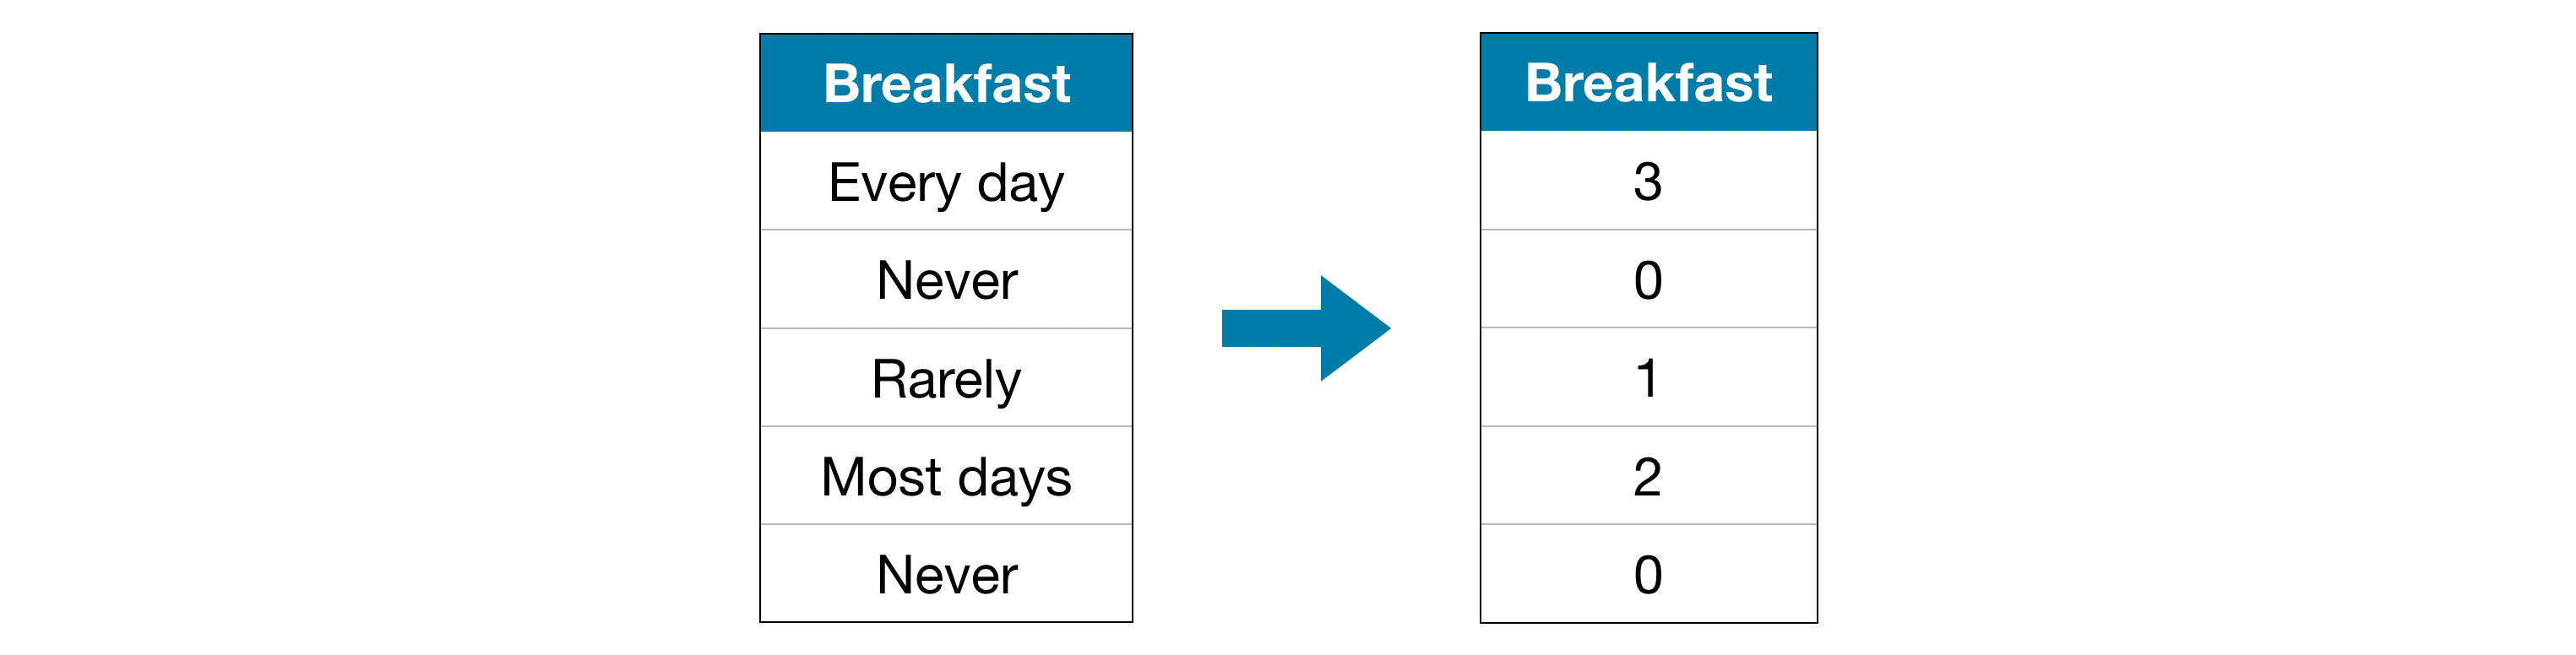

This approach assumes an ordering of the categories: "Never" (0) < "Rarely" (1) < "Most days" (2) < "Every day" (3).

This assumption makes sense in this example, because there is an indisputable ranking to the categories. Not all categorical variables have a clear ordering in the values, but we refer to those that do as ordinal variables. For tree-based models (like decision trees and random forests), you can expect ordinal encoding to work well with ordinal variables.

3) One-Hot Encoding

- One-hot encoding creates new columns indicating the presence (or absence) of each possible value in the original data. To understand this, we'll work through an example.

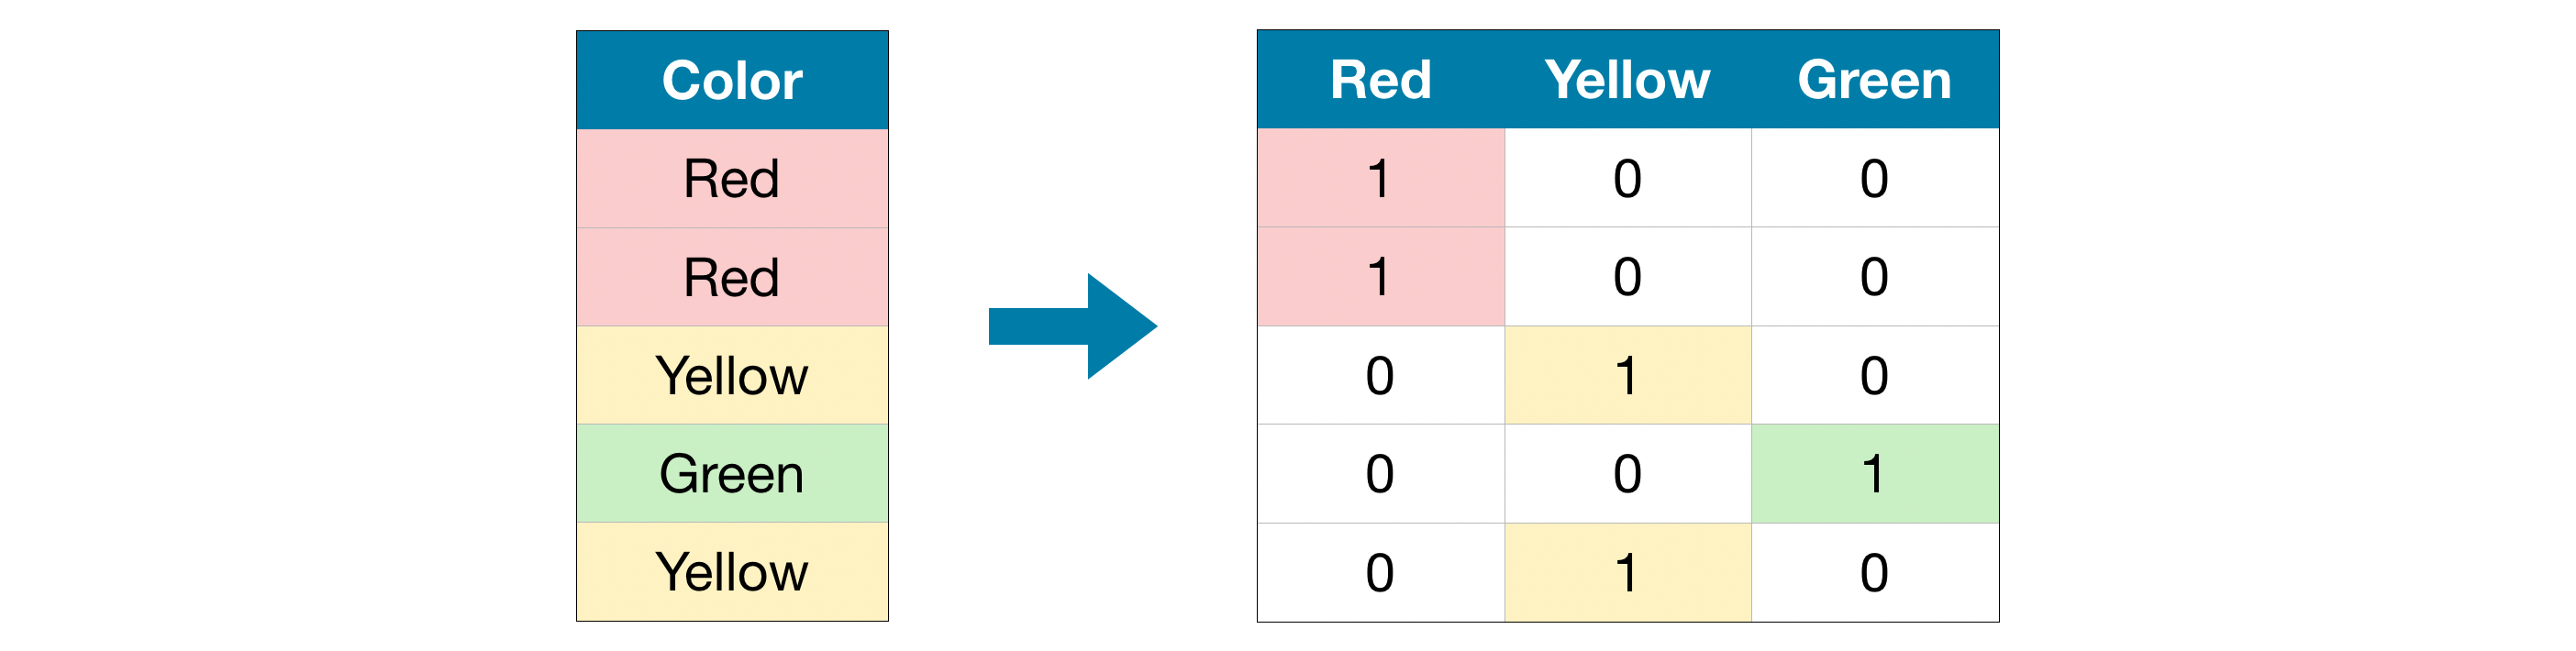

In the original dataset, "Color" is a categorical variable with three categories: "Red", "Yellow", and "Green". The corresponding one-hot encoding contains one column for each possible value, and one row for each row in the original dataset. Wherever the original value was "Red", we put a 1 in the "Red" column; if the original value was "Yellow", we put a 1 in the "Yellow" column, and so on.

In contrast to ordinal encoding, one-hot encoding does not assume an ordering of the categories. Thus, you can expect this approach to work particularly well if there is no clear ordering in the categorical data (e.g., "Red" is neither more nor less than "Yellow"). We refer to categorical variables without an intrinsic ranking as nominal variables.

One-hot encoding generally does not perform well if the categorical variable takes on a large number of values (i.e., you generally won't use it for variables taking more than 15 different values).

In [14]:
X = df[features_categorical]
y = df.Price

X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.3, random_state=100)

In [15]:
###Checking if value in categorical columns are same in both training and validation datasets, else it
# throw error while validation for unknown value not encoded.


## Checking categorical columns

X_train_num_cols = X_train.select_dtypes(exclude='object')
X_validate_num_cols = X_validate.select_dtypes(exclude='object')

print(f'Numerical columns in training dataset: \n\n{list(X_train_num_cols.columns)}')
print(f'Numerical columns in validation dataset: \n\n{list(X_validate_num_cols.columns)}')
X_train_categorical_cols = X_train.select_dtypes(include='object')
X_validate_categorical_cols = X_validate.select_dtypes(include='object')

print(f'Categorical columns in training dataset: \n\n{X_train_categorical_cols.columns.to_list()}')
print(f'Categorical columns in validation dataset: \n\n{X_validate_categorical_cols.columns.to_list()}')

Numerical columns in training dataset: 

['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']
Numerical columns in validation dataset: 

['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']
Categorical columns in training dataset: 

['Type', 'Method', 'Regionname', 'Suburb']
Categorical columns in validation dataset: 

['Type', 'Method', 'Regionname', 'Suburb']


#### Checking category mismatch

- Fitting an ordinal encoder to a column in the training data creates a corresponding integer-valued label for each unique value that appears in the training data. In the case that the validation data contains values that don't also appear in the training data, the encoder will throw an error, because these values won't have an integer assigned to them. Notice that the 'Condition2' column in the validation data contains the values 'RRAn' and 'RRNn', but these don't appear in the training data -- thus, if we try to use an ordinal encoder with scikit-learn, the code will throw an error.

In [16]:
good_cat_cols = [col for col in X_train_categorical_cols if 
                    set(X_validate_categorical_cols[col]).issubset(set(X_train_categorical_cols[col]))]

# bad_cat_cols = [col for col in X_train_categorical_cols if col not in good_cat_cols]
bad_cat_cols = list(set(X_train_categorical_cols) - set(good_cat_cols))
print(f'Columns with equal categorical values in both training and validation dataset:\n\n {good_cat_cols}')
print(f'Columns with un-equal categorical values in both training and validation dataset:\n\n {bad_cat_cols}')

Columns with equal categorical values in both training and validation dataset:

 ['Type', 'Method', 'Regionname']
Columns with un-equal categorical values in both training and validation dataset:

 ['Suburb']


In [17]:
# list(map(lambda col: X_train[col].nunique(), X_train_categorical_cols))

In [18]:
# Get number of unique entries in each column with categorical data
object_nunique = list(map(lambda col: X_train[col].nunique(), X_train_categorical_cols))
d = dict(zip(X_train_categorical_cols, object_nunique))

# Print number of unique entries by column, in ascending order
sorted(d.items(), key=lambda x: x[1])

[('Type', 3), ('Method', 5), ('Regionname', 8), ('Suburb', 305)]

In [55]:
from sklearn.preprocessing import OneHotEncoder
OHEncoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = pd.DataFrame(OHEncoder.fit_transform(X_train[good_cat_cols]))
X_validate_ohe = pd.DataFrame(OHEncoder.transform(X_validate[good_cat_cols]))

X_train_ohe.columns = X_train_ohe.columns.astype(str)
X_validate_ohe.columns = X_validate_ohe.columns.astype(str)

In [45]:
X_train_ohe

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9501,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9502,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9503,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9504,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [56]:
X_train_ohe.index  =X_train.index
X_validate_ohe.index  =X_validate.index

In [57]:
print(X_validate_ohe.shape)
X_train_ohe

(4074, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
4360,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
11313,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3280,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9293,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10678,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12119,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8039,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6936,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [58]:
X_train

,Type,Method,Regionname,Suburb,Rooms,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Propertycount
4360,u,VB,Northern Metropolitan,North Melbourne,2,2.0,1.0,1.0,1588.0,71.0,1970.0,6821.0
11313,h,S,Southern Metropolitan,Caulfield East,4,4.0,2.0,1.0,642.0,NaN,NaN,608.0
3280,h,S,Eastern Metropolitan,Heidelberg West,3,3.0,2.0,0.0,643.0,NaN,NaN,2674.0
9293,h,S,Northern Metropolitan,Preston,3,3.0,1.0,1.0,263.0,123.0,2000.0,14577.0
10678,h,S,Eastern Metropolitan,Glen Waverley,3,3.0,1.0,2.0,778.0,NaN,NaN,15321.0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,h,S,Southern Metropolitan,Albert Park,2,2.0,1.0,0.0,159.0,NaN,NaN,3280.0
12119,u,S,Northern Metropolitan,Pascoe Vale,2,2.0,1.0,2.0,189.0,NaN,1980.0,7485.0
8039,h,SP,Southern Metropolitan,Kew,5,5.0,3.0,1.0,520.0,NaN,NaN,10331.0
6936,h,S,Northern Metropolitan,Fawkner,3,3.0,1.0,2.0,628.0,NaN,NaN,5070.0


In [59]:
X_validate_ohe

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
8221,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13355,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10638,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4280,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6518,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11655,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8077,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12497,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5204,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [60]:
X_train_num = X_train.drop(good_cat_cols, axis = 1)
X_validate_num = X_validate.drop(good_cat_cols, axis = 1)

In [66]:
x_train_ohen = pd.concat([X_train_ohe, X_train_num], axis = 1)
x_validate_ohen = pd.concat([X_validate_ohe, X_validate_num], axis = 1)

In [67]:
print(x_validate_ohen.shape)
X_validate_num.shape

(4074, 25)


(4074, 9)

In [73]:
x_train_ohen.drop('Suburb', inplace = True, axis=1)
x_validate_ohen.drop('Suburb', inplace = True, axis = 1 )

In [75]:
x_train_ohen_impute = pd.DataFrame(imputer.fit_transform(x_train_ohen))
x_validate_ohen_impute = pd.DataFrame(imputer.transform(x_validate_ohen))

In [76]:
model = RandomForestRegressor(n_estimators=10, random_state=10)
model.fit(x_train_ohen_impute, y_train )
predictions = model.predict(x_validate_ohen_impute)
mae = mean_absolute_error(predictions, y_validate)

In [77]:
mae

224455.26513019518

# XGBoost (Extreme Gradient Boosting)

## IntroDuction

## Gradient Boosting
Gradient boosting is a method that goes through cycles to iteratively add models into an ensemble.

It begins by initializing the ensemble with a single model, whose predictions can be pretty naive. (Even if its predictions are wildly inaccurate, subsequent additions to the ensemble will address those errors.)

Then, we start the cycle:

- First, we use the current ensemble to generate predictions for each observation in the dataset. To make a prediction, we add the predictions from all models in the ensemble.
- These predictions are used to calculate a loss function (like mean squared error, for instance).
- Then, we use the loss function to fit a new model that will be added to the ensemble. Specifically, we determine model parameters so that adding this new model to the ensemble will reduce the loss. (Side note: The "gradient" in "gradient boosting" refers to the fact that we'll use gradient descent on the loss function to determine the parameters in this new model.)
- Finally, we add the new model to ensemble, and ...
- ... repeat!

    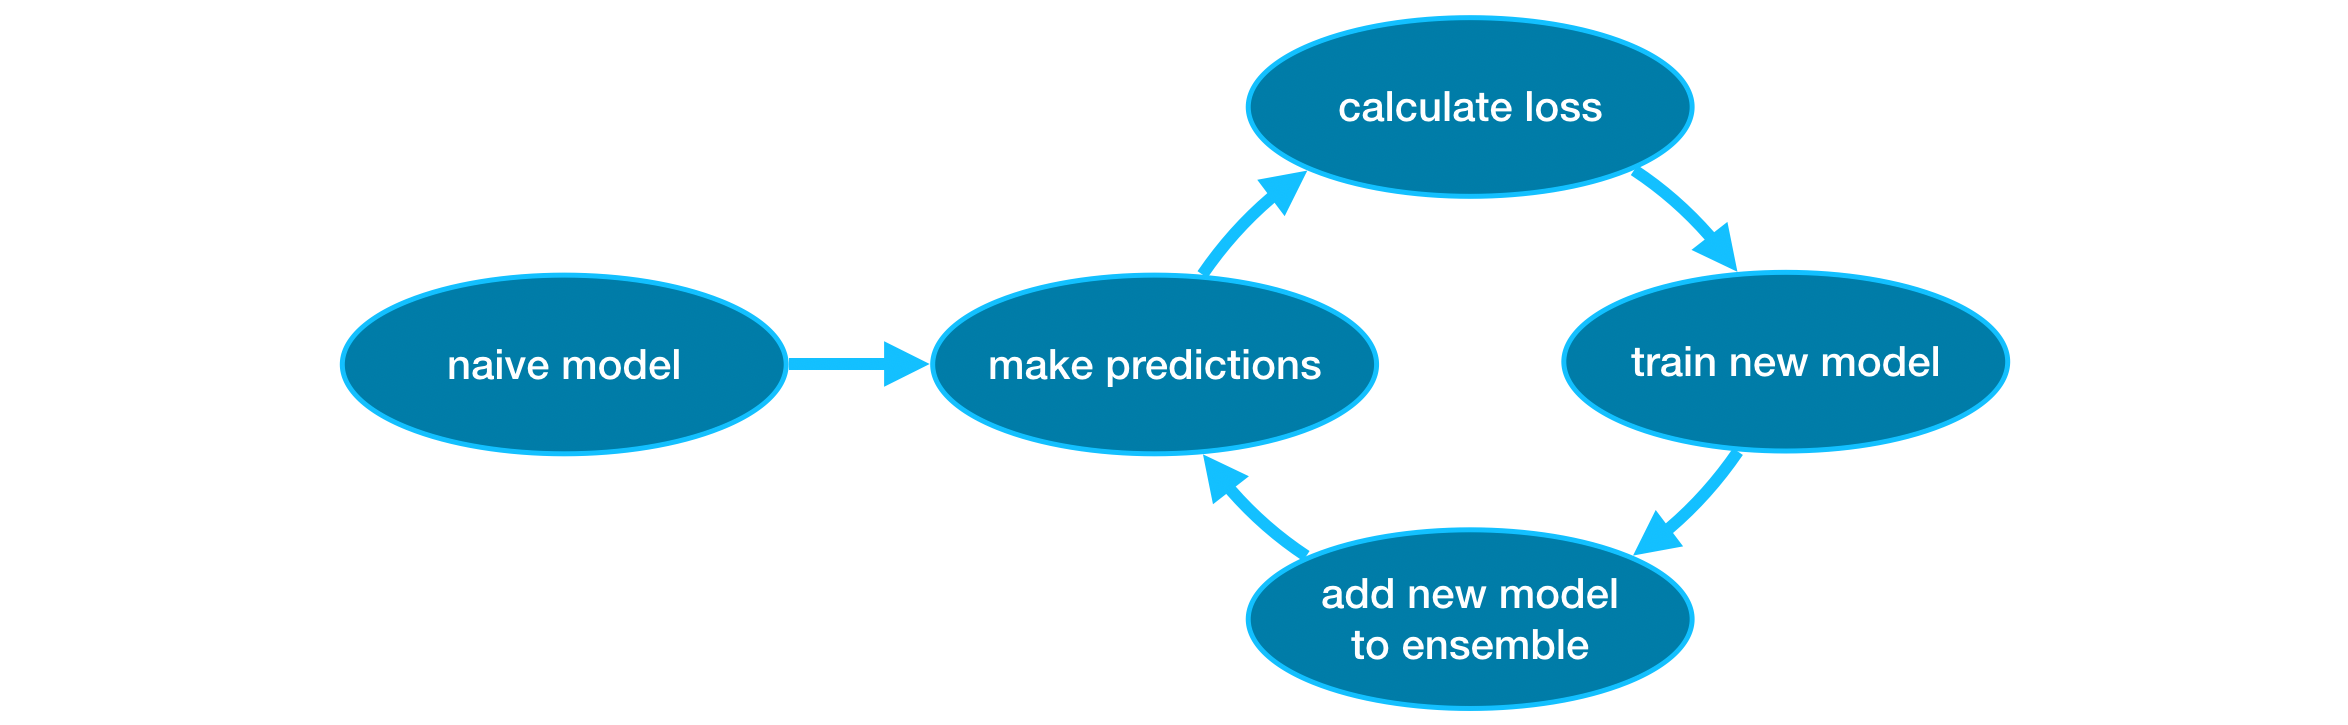

In this example, you'll work with the XGBoost library. XGBoost stands for extreme gradient boosting, which is an implementation of gradient boosting with several additional features focused on performance and speed. (Scikit-learn has another version of gradient boosting, but XGBoost has some technical advantages.)

In the next code cell, we import the scikit-learn API for XGBoost (xgboost.XGBRegressor). This allows us to build and fit a model just as we would in scikit-learn. As you'll see in the output, the XGBRegressor class has many tunable parameters

```python
    from xgboost import XGBRegressor

    my_model = XGBRegressor()
    my_model.fit(X_train, y_train)
```

## Parameter Tuning
XGBoost has a few parameters that can dramatically affect accuracy and training speed. The first parameters you should understand are:

`n_estimators`
`n_estimators` specifies how many times to go through the modeling cycle described above. It is equal to the number of models that we include in the ensemble.

Too low a value causes underfitting, which leads to inaccurate predictions on both training data and test data.
Too high a value causes overfitting, which causes accurate predictions on training data, but inaccurate predictions on test data (which is what we care about).
Typical values range from 100-1000, though this depends a lot on the learning_rate parameter discussed below.

```python
    my_model = XGBRegressor(n_estimators=500)
    my_model.fit(X_train, y_train)
```

###############################################################


### early_stopping_rounds
`early_stopping_rounds` offers a way to automatically find the ideal value for n_estimators. Early stopping causes the model to stop iterating when the validation score stops improving, even if we aren't at the hard stop for `n_estimators`. It's smart to set a high value for n_estimators and then use `early_stopping_rounds` to find the optimal time to stop iterating.

Since random chance sometimes causes a single round where validation scores don't improve, you need to specify a number for how many rounds of straight deterioration to allow before stopping. Setting `early_stopping_rounds`=5 is a reasonable choice. In this case, we stop after 5 straight rounds of deteriorating validation scores.

When using `early_stopping_rounds`, you also need to set aside some data for calculating the validation scores - this is done by setting the eval_set parameter.

```python
    my_model = XGBRegressor(n_estimators=500)
    my_model.fit(X_train, y_train, 
                early_stopping_rounds=5, 
                eval_set=[(X_valid, y_valid)],
                verbose=False)
```


###############################################################


`learning_rate¶`
Instead of getting predictions by simply adding up the predictions from each component model, we can multiply the predictions from each model by a small number (known as the learning rate) before adding them in.

This means each tree we add to the ensemble helps us less. So, we can set a higher value for `n_estimators` without overfitting. If we use early stopping, the appropriate number of trees will be determined automatically.

In general, a small learning rate and large number of estimators will yield more accurate XGBoost models, though it will also take the model longer to train since it does more iterations through the cycle. As default, XGBoost sets `learning_rate`=0.1.

```python
    my_model = XGBRegressor(n_estimators=1000, learning_rate=0.05)
    my_model.fit(X_train, y_train, 
                early_stopping_rounds=5, 
                eval_set=[(X_valid, y_valid)], 
                verbose=False)
```


##########################################################################


`n_jobs`
On larger datasets where runtime is a consideration, you can use parallelism to build your models faster. It's common to set the parameter `n_jobs` equal to the number of cores on your machine. On smaller datasets, this won't help.

The resulting model won't be any better, so micro-optimizing for fitting time is typically nothing but a distraction. But, it's useful in large datasets where you would otherwise spend a long time waiting during the `fit` command.

```python
    my_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=4)
    my_model.fit(X_train, y_train, 
                early_stopping_rounds=5, 
                eval_set=[(X_valid, y_valid)], 
                verbose=False)
```

## Data Leakage

**Data leakage** (or leakage) happens when your training data contains information about the target, but similar data will not be available when the model is used for prediction. This leads to high performance on the training set (and possibly even the validation data), but the model will perform poorly in production.

In other words, leakage causes a model to look accurate until you start making decisions with the model, and then the model becomes very inaccurate.

There are two main types of leakage: **target leakage** and **train-test contamination**.

**Target leakage**

Target leakage occurs when your predictors include data that will not be available at the time you make predictions. It is important to think about target leakage in terms of the timing or chronological order that data becomes available, not merely whether a feature helps make good predictions.

An example will be helpful. Imagine you want to predict who will get sick with pneumonia. The top few rows of your raw data look like this:


**got_pneumonia** |  **age**	|   **weight**	|  **male**	| **took_antibiotic_medicine**	...
    
        False	65	100	False	False	...

        False	72	130	True	False	...

        True	58	100	False	True	...


People take antibiotic medicines after getting pneumonia in order to recover. The raw data shows a strong relationship between those columns, but took_antibiotic_medicine is frequently changed after the value for got_pneumonia is determined. This is target leakage.

The model would see that anyone who has a value of False for took_antibiotic_medicine didn't have pneumonia. Since validation data comes from the same source as training data, the pattern will repeat itself in validation, and the model will have great validation (or cross-validation) scores.

But the model will be very inaccurate when subsequently deployed in the real world, because even patients who will get pneumonia won't have received antibiotics yet when we need to make predictions about their future health.

To prevent this type of data leakage, any variable updated (or created) after the target value is realized should be excluded.

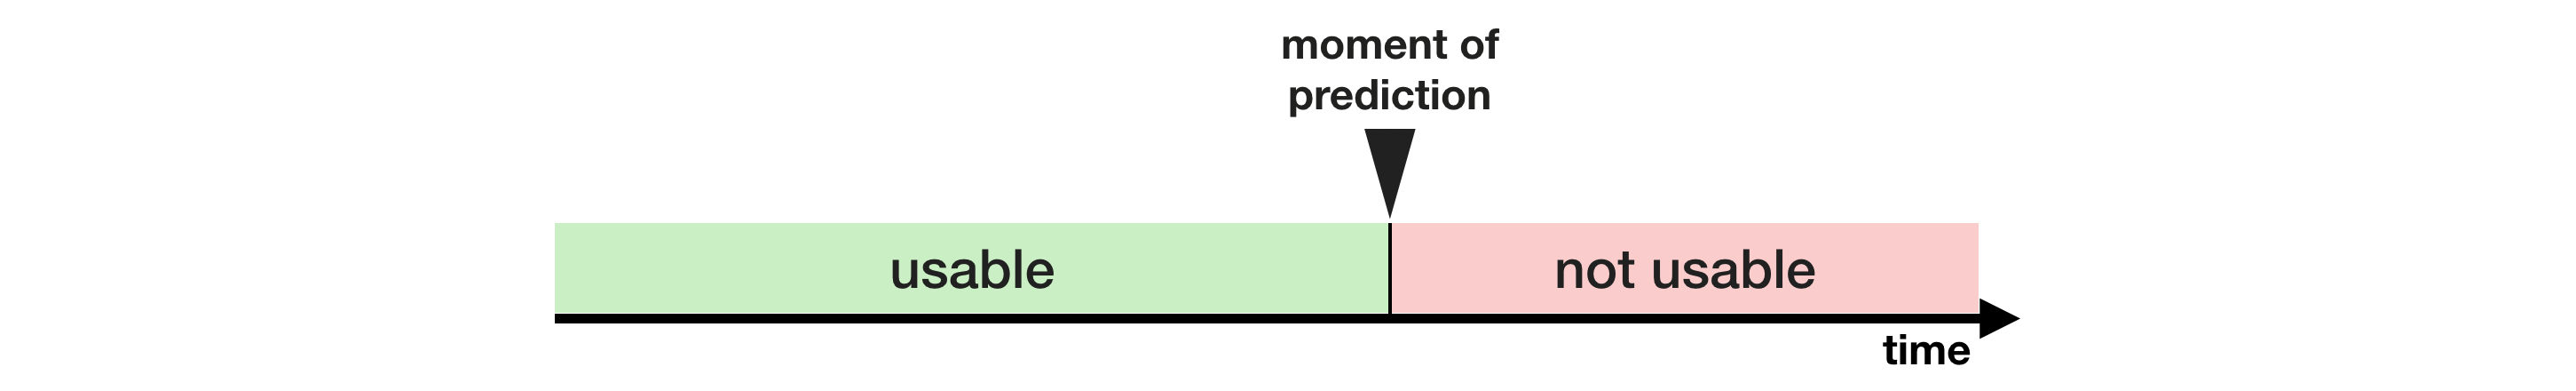

**Train-Test Contamination**

A different type of leak occurs when you aren't careful to distinguish training data from validation data.

Recall that validation is meant to be a measure of how the model does on data that it hasn't considered before. You can corrupt this process in subtle ways if the validation data affects the preprocessing behavior. This is sometimes called train-test contamination.

For example, imagine you run preprocessing (like fitting an imputer for missing values) before calling train_test_split(). The end result? Your model may get good validation scores, giving you great confidence in it, but perform poorly when you deploy it to make decisions.

After all, you incorporated data from the validation or test data into how you make predictions, so the may do well on that particular data even if it can't generalize to new data. This problem becomes even more subtle (and more dangerous) when you do more complex feature engineering.

If your validation is based on a simple train-test split, exclude the validation data from any type of fitting, including the fitting of preprocessing steps. This is easier if you use scikit-learn pipelines. When using cross-validation, it's even more critical that you do your preprocessing inside the pipeline!

Example
In this example, you will learn one way to detect and remove target leakage.

We will use a dataset about credit card applications and skip the basic data set-up code. The end result is that information about each credit card application is stored in a DataFrame X. We'll use it to predict which applications were accepted in a Series y.

